In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [6]:
class Company:
  """It represents a single business entity and manages the retrieval and standardization of its financial data."""
  def __init__(self, ticker_symbol:str):
    self.ticker_symbol = ticker_symbol.upper()
    self.ticker = yf.Ticker(self.ticker_symbol)
    self.raw_income_stmt = None
    self.raw_balance_sheet = None
    self.info = {}
    self.ebitda_source = None
    self.current_price = 0.0
    self.shares_outstanding = 0.0
    self.market_cap = 0.0
    self.enterprise_value = 0.0
    self.revenue = 0.0
    self.ebitda = 0.0
    self.net_income = 0.0
    self.cash = 0.0
    self.debt = 0.0

    self._load_data()


  def _safe_extract(self, dataframe: pd.DataFrame, keys: list[str]) -> float:
    for key in keys:
      if key in dataframe.index:
        return float(dataframe.loc[key].iloc[0])

    raise KeyError(f"None of the following fields "
        f"were found: {keys}")

  def _load_data(self):
    """Private method for downloading and mapping data from YFinance."""
    try:
      self.raw_income_stmt = self.ticker.financials
      self.raw_balance_sheet = self.ticker.balance_sheet
      self.info = self.ticker.info

      latest_year = self.raw_income_stmt.columns[0]
      self.revenue = self._safe_extract(self.raw_income_stmt,["Total Revenue","Revenue","Operating Revenue"])
      self.net_income = float(self.raw_income_stmt.loc["Net Income"].iloc[0])

      try:
        self.ebitda = self._safe_extract(self.raw_income_stmt, ["EBITDA","Normalized EBITDA"])
        self.ebitda_source = "EBITDA"

      except KeyError:
        self.ebitda = self._safe_extract(self.raw_income_stmt, ["Operating Income", "Operating Income Loss"])

        self.ebitda_source = "Operating Income"

      self.cash = float(self.raw_balance_sheet.loc["Cash And Cash Equivalents"].iloc[0])

      try:
        self.debt = float(self.raw_balance_sheet.loc["Total Debt"].iloc[0])
      except KeyError:
        short_debt = float(self.raw_balance_sheet.get("Short Term Debt", pd.Series([0])).iloc[0])
        long_debt = float(self.raw_balance_sheet.get("Long Term Debt", pd.Series([0])).iloc[0])
        self.debt = short_debt + long_debt

      self.current_price = float(self.info.get("currentPrice", 0.0))
      self.shares_outstanding = float(self.info.get("sharesOutstanding", 0.0))
      self.market_cap = float(self.info.get("marketCap", 0.0))
      self.enterprise_value = self.market_cap - self.cash + self.debt

    except Exception as e:
      raise ValueError(f"Error loading data for {self.ticker_symbol}: {e}.")
  @property
  def ev_to_revenue(self) -> float:
    """Calculate the EV/Sales multiple."""
    return self.enterprise_value/self.revenue if self.revenue else 0.0

  @property
  def ev_to_ebitda(self) -> float:
    """Calculate EV/Ebitda."""
    return self.enterprise_value/self.ebitda if self.ebitda else 0.0

  @property
  def price_to_earnings(self) -> float:
    """Calculate Price/Earnings."""
    return self.market_cap/self.net_income if self.net_income else 0.0

  @property
  def eps(self) -> float:
    """Calculate the standalone earnings per share (EPS)."""
    return self.net_income/self.shares_outstanding if self.shares_outstanding else 0.0

  def get_summary_table(self) -> pd.Series:
    """Returns the key metrics in a human-readable format ($B)."""
    return pd.Series({
        "Price ($)": self.current_price,
        "Market Cap ($B)": self.market_cap / 1e9,
        "Enterprise Value ($B)": self.enterprise_value / 1e9,
        "Revenue ($B)": self.revenue / 1e9,
        "EBITDA ($B)": self.ebitda / 1e9,
        "Net Income ($B)": self.net_income / 1e9,
        "EV / Revenue": self.ev_to_revenue,
        "EV / EBITDA": self.ev_to_ebitda,
        "P/E Ratio": self.price_to_earnings,
        "EPS Standalone ($)": self.eps}, name=self.ticker_symbol)

class MA:
  """Manages the financial modeling of the M&A transaction by analyzing cash and stock scenarios, including synergies and premiums."""
  def __init__(self, buyer:Company, target:Company, premium_pct:float, synergies:float):
    self.buyer = buyer
    self.target = target
    self.premium_pct = premium_pct
    self.synergies = synergies

  @property
  def offer_price_per_share(self) -> float:
    """Offer price per share of the target company, including the premium."""
    return self.target.current_price * (1 + self.premium_pct)

  @property
  def equity_purchase_price(self) -> float:
    """Total value of the shares (Equity Value) to be purchased at the offer price."""
    return self.offer_price_per_share*self.target.shares_outstanding

  @property
  def transaction_enterprise_value(self) -> float:
    """Enterprise value of the transaction (includes debt and excludes the target's cash)."""
    return self.equity_purchase_price + self.target.debt - self.target.cash

  def analyze_cash_deal(self, interest_rate_on_debt:float=0.04) -> pd.Series:
    """Simulates a transaction financed entirely in cash. If the buyer does not have enough cash, they issue debt at the specified rate."""
    cash_needed = self.equity_purchase_price
    available_cash = self.buyer.cash

    if available_cash >= cash_needed:
      new_debt_issued = 0.0
      foregone_interest = (cash_needed * 0.02)
      interest_expense = 0.0
    else:
      new_debt_issued = cash_needed - available_cash
      foregone_interest = available_cash * 0.02
      interest_expense = new_debt_issued * interest_rate_on_debt

    tax_rate = 0.21
    net_finance_cost = ((interest_expense + foregone_interest) * (1 - tax_rate))
    combined_net_income = (self.buyer.net_income + self.target.net_income + self.synergies - net_finance_cost)

    combined_shares = self.buyer.shares_outstanding
    combined_eps = combined_net_income / combined_shares

    return self._generate_report_series("100% Cash", combined_eps, combined_net_income, combined_shares)

  def analyze_stock_deal(self) -> pd.Series:
    """Simulate a transaction financed entirely through a stock-for-stock swap."""
    exchange_ratio = self.offer_price_per_share / self.buyer.current_price
    new_shares_issued = self.target.shares_outstanding * exchange_ratio

    combined_net_income = (self.buyer.net_income + self.target.net_income + self.synergies)
    combined_shares = self.buyer.shares_outstanding + new_shares_issued
    combined_eps = combined_net_income / combined_shares

    return self._generate_report_series("100% Stock", combined_eps, combined_net_income, combined_shares)

  def _generate_report_series(self, deal_type:str, comb_eps: float, comb_net_inc: float, comb_shares: float) -> pd.Series:
    """A private utility method for formatting the analysis output."""
    eps_change_abs = comb_eps - self.buyer.eps
    if self.buyer.eps != 0:
      eps_change_pct = (eps_change_abs /self.buyer.eps) * 100
    else:
      eps_change_pct = np.nan

    status = "ACCRETIVE" if eps_change_abs > 0 else "DILUTIVE"
    return pd.Series({
        "Deal Type": deal_type,
        "Offer Price Target ($)": self.offer_price_per_share,
        "Equity Purchase Value ($B)": self.equity_purchase_price / 1e9,
        "Combined Net Income ($B)": comb_net_inc / 1e9,
        "Post-Merger Shares (M)": comb_shares / 1e6,
        "EPS Post-Merger ($)": comb_eps,
        "EPS Impact (%)": eps_change_pct,
        "Operation Result": status})

class FinancialVisualizer:
  """Class dedicated to generating financial charts and sensitivity analysis for M&A transactions."""
  def __init__(self, transaction_model:MA):
    self.tx = transaction_model
    plt.style.use("seaborn-v0_8-whitegrid")

  def plot_eps_sensitivity_analysis(self, min_premium:float=0.1, max_premium:float=0.7):
    """Generate and display a sensitivity chart that compares the impact on EPS as the acquisition premium (cash vs. stock) varies."""
    original_premium = self.tx.premium_pct
    premiums = np.arange(min_premium, max_premium + 0.05, 0.05)
    cash_impacts = []
    stock_impacts = []

    for p in premiums:
      self.tx.premium_pct = p

      cash_res = self.tx.analyze_cash_deal()
      stock_res = self.tx.analyze_stock_deal()

      cash_impacts.append(cash_res["EPS Impact (%)"])
      stock_impacts.append(stock_res["EPS Impact (%)"])

    self.tx.premium_pct = original_premium

    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    ax.plot(premiums * 100, cash_impacts, marker="o", linewidth=2, color="#1f77b4", label="100% Cash")
    ax.plot(premiums * 100, stock_impacts, marker="s", linewidth=2, color="#ff7f0e", label="100% Stock")
    ax.axhline(0, color="red", linestyle="--", alpha=0.6, label="Breakeven")
    ax.set_title(f"EPS Sensitivity Analysis: {self.tx.buyer.ticker_symbol} buys {self.tx.target.ticker_symbol}", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Acquisition Premium (%)", fontsize=12, labelpad=10)
    ax.set_ylabel("Impact on the Acquirer's EPS (%)", fontsize=12, labelpad=10)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=2))
    ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(
            {"Target Premium (%)": premiums * 100,
             "Cash Impact (%)": cash_impacts,
             "Stock Impact (%)": stock_impacts}).set_index("Target Premium (%)")


      LAUNCH OF AN END-TO-END QUANTITATIVE M&A MODEL (2026)      

[STEP 1/3] Retrieval of financial statements and real-time market data

>>> COMPANY CLASS: STANDALONE BUSINESS METRICS
------------------------------------------------------------
      Price ($)  Market Cap ($B)  Enterprise Value ($B)  Revenue ($B)  EBITDA ($B)  Net Income ($B)  EV / Revenue  EV / EBITDA  P/E Ratio  EPS Standalone ($)
MSFT     411.74          3058.58                3088.93        281.72       160.16           101.83         10.96        19.29      30.04               13.71
PINS      21.99            12.32                  11.61          4.22         0.35             0.42          2.75        33.65      29.55                0.87
------------------------------------------------------------

[STEP 2/3] Structuring the M&A

>>> M&A CLASS: BASIC FINANCIAL STRUCTURE REPORT
Note: The target is valued at a premium of 30% above the current price.
Estimated standalone earnings per share for MSFT: $13.71 per sha

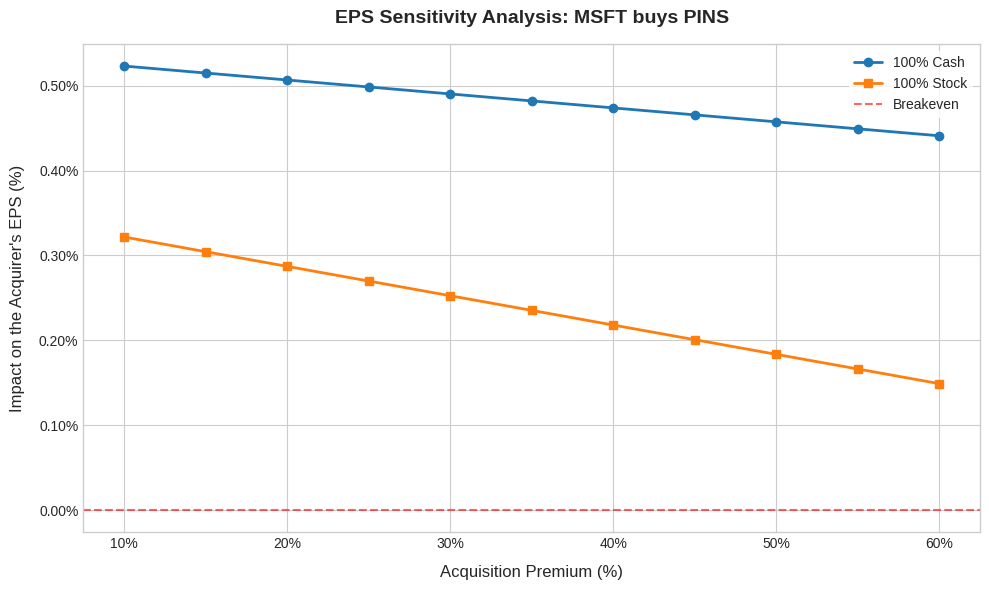


Sensitivity Table (% Impact on the Buyer's EPS):
------------------------------------------------------------
                    Cash Impact (%)  Stock Impact (%)
Target Premium (%)                                   
10.0                          0.523             0.322
15.0                          0.515             0.304
20.0                          0.507             0.287
25.0                          0.498             0.270
30.0                          0.490             0.253
35.0                          0.482             0.235
40.0                          0.474             0.218
45.0                          0.466             0.201
50.0                          0.457             0.183
55.0                          0.449             0.166
60.0                          0.441             0.149
------------------------------------------------------------


In [7]:
if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("      LAUNCH OF AN END-TO-END QUANTITATIVE M&A MODEL (2026)      ")
    print("=" * 60)
    print("\n[STEP 1/3] Retrieval of financial statements and real-time market data")
    buyer_co = Company("MSFT")
    target_co = Company("PINS")
    comparison_df = pd.DataFrame([buyer_co.get_summary_table(), target_co.get_summary_table()])
    print("\n>>> COMPANY CLASS: STANDALONE BUSINESS METRICS")
    print("-" * 60)
    print(comparison_df.round(2).to_string())
    print("-" * 60)
    print("\n[STEP 2/3] Structuring the M&A")
    target_premium = 0.30
    estimated_synergies = 300e6

    deal = MA(buyer=buyer_co, target=target_co, premium_pct=target_premium, synergies=estimated_synergies)
    print("\n>>> M&A CLASS: BASIC FINANCIAL STRUCTURE REPORT")
    print(f"Note: The target is valued at a premium of {target_premium*100:.0f}% above the current price.")
    print(f"Estimated standalone earnings per share for {buyer_co.ticker_symbol}: ${buyer_co.eps:.2f} per share.")
    print("-" * 60)
    cash_summary = deal.analyze_cash_deal(
    interest_rate_on_debt=0.045)
    stock_summary = deal.analyze_stock_deal()

    deal_comparison_df = pd.DataFrame([cash_summary, stock_summary]).set_index("Deal Type")
    print(deal_comparison_df.round(2).to_string())
    print("-" * 60)
    print("\n[STEP 3/3] Generating a sensitivity analysis on the premium")
    visualizer = FinancialVisualizer(transaction_model=deal)
    print("\n>>> FINANCIALVISUALIZER CLASS: PLOT & MATRIX RENDERING")
    sensitivity_matrix = visualizer.plot_eps_sensitivity_analysis(min_premium=0.10, max_premium=0.60)

    print("\nSensitivity Table (% Impact on the Buyer's EPS):")
    print("-" * 60)
    print(sensitivity_matrix.round(3).to_string())
    print("-" * 60)